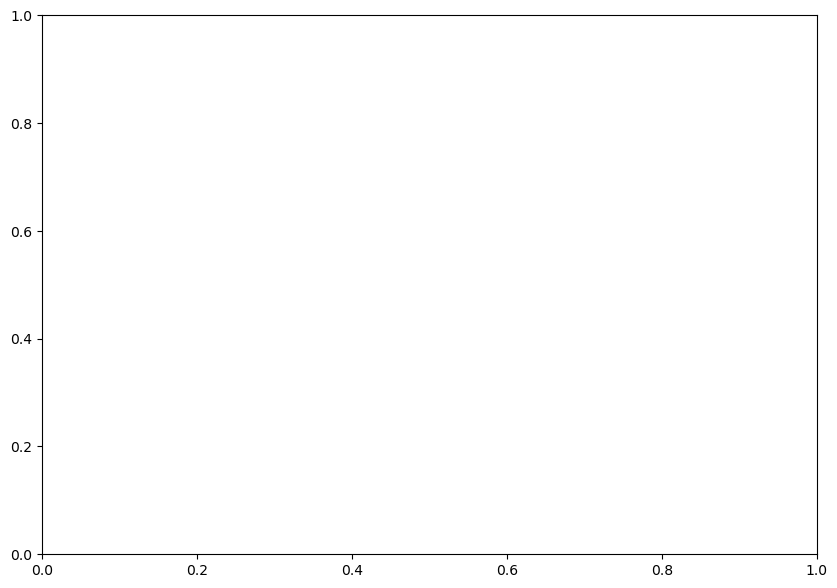

/opt/conda/lib/python3.11/site-packages/matplotlib/animation.py:892: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(
/tmp/ipykernel_39389/1602360699.py:128: UserWarning: Glyph 20462 (\N{CJK UNIFIED IDEOGRAPH-4FEE}) missing from current font.
  ani.save('wave_simulation.gif', writer='pillow', fps=30)
/tmp/ipykernel_39389/1602360699.py:128: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from current font.
  ani.save('wave_simulation.gif', writer='pillow', fps=30)
/tmp/ipykernel_39389/1602360699.py:128: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from current font.
  ani.save('wave_simulation.gif', writer='pillow', fps=30)
/tmp/ipykernel_39389/1602360699.py:128: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from current font.
 

アニメーションの生成中...（少し時間がかかります）


/tmp/ipykernel_39389/1602360699.py:128: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from current font.
  ani.save('wave_simulation.gif', writer='pillow', fps=30)
/tmp/ipykernel_39389/1602360699.py:128: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from current font.
  ani.save('wave_simulation.gif', writer='pillow', fps=30)
/tmp/ipykernel_39389/1602360699.py:128: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from current font.
  ani.save('wave_simulation.gif', writer='pillow', fps=30)
/tmp/ipykernel_39389/1602360699.py:128: UserWarning: Glyph 12434 (\N{HIRAGANA LETTER WO}) missing from current font.
  ani.save('wave_simulation.gif', writer='pillow', fps=30)
/tmp/ipykernel_39389/1602360699.py:128: UserWarning: Glyph 28288 (\N{CJK UNIFIED IDEOGRAPH-6E80}) missing from current font.
  ani.save('wave_simulation.gif', writer='pillow', fps=30)
/tmp/ipykernel_39389/1602360699.py:128: UserWarning: Glyph 12383 (\N{HIRAGANA LETTER TA}

完了しました。フォルダ内の 'wave_simulation.gif' を開いてください。


<Figure size 640x480 with 0 Axes>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- 設定 ---
L = 2 * np.pi          # 空間の長さ
x = np.linspace(0, L, 500) # 空間座標のメッシュ
frames = 300           # 総フレーム数
interval = 40          # フレーム間の時間(ms)
split_frame = frames // 2 # 前半と後半の切り替えフレーム

# --- 修正前（パート1）のパラメータ ---
N_points = 25          # 空間に配置する「バネ」の数
np.random.seed(101)    # 乱数シードの固定
x_points = np.linspace(0.2, L-0.2, N_points) # バネの位置
# 各バネの角振動数と初期位相をランダムに設定（バラバラ感を出す）
omegas_rnd = np.random.uniform(2, 8, N_points)
phis_rnd = np.random.uniform(0, 2*np.pi, N_points)
amplitudes_rnd = np.random.uniform(0.5, 1.2, N_points)

# --- 修正後（パート2）のパラメータ ---
# 異なる波長（モード）の設定
# k: 波数, A: 最大振幅, omega: 振動数, phi: 初期位相
modes = [
    {'k': 1, 'A': 1.2, 'omega': 2.0, 'phi': 0},
    {'k': 2, 'A': 0.8, 'omega': 3.5, 'phi': np.pi/3},
    {'k': 3, 'A': 0.5, 'omega': 5.0, 'phi': np.pi/2},
    {'k': 5, 'A': 0.3, 'omega': 7.5, 'phi': np.pi},
]

# --- 描画の準備 ---
fig, ax = plt.subplots(figsize=(10, 7))

def update(frame):
    ax.clear()
    # 時間変数の設定（スムーズなアニメーションのため）
    t = frame * 0.05

    # ==========================================
    # 前半：修正前（空間の各点に独立したバネ）
    # ==========================================
    if frame < split_frame:
        ax.set_title("修正前：空間の各点に小さなバネがあって、\nそれぞれが勝手にビヨンビヨンしている。", fontsize=16, pad=20)
        ax.set_ylim(-2, 2)
        ax.set_xlim(0, L)
        ax.set_xticks([]) # X軸の数値を消す
        ax.set_yticks([]) # Y軸の数値を消す
        ax.axhline(0, color='black', lw=1.5, alpha=0.7) # 基準線

        # 各点のバネの動きを計算
        y_points = amplitudes_rnd * np.sin(omegas_rnd * t + phis_rnd)

        # バネと質点を描画
        for i in range(N_points):
            # バネに見立てた線
            ax.plot([x_points[i], x_points[i]], [0, y_points[i]], color='gray', alpha=0.6, lw=2, linestyle=':')
            # 質点（ボール）
            color_intensity = (y_points[i] + 1.5) / 3 # 位置によって少し色を変える
            ax.plot(x_points[i], y_points[i], 'o', markersize=12, color=plt.cm.viridis(color_intensity), markeredgecolor='black')
        
        # 説明テキスト
        ax.text(L/2, 1.6, "※隣の点とのつながり（相互作用）が見えない\nこれでは波が伝わらない！", 
                ha='center', fontsize=13, color='red', bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))

    # ==========================================
    # 後半：修正後（モードの重ね合わせ）
    # ==========================================
    else:
        # 後半用の時間調整
        t_mod = (frame - split_frame) * 0.05

        ax.set_title("修正後：空間全体を満たす「異なる波長の波（モード）」が重なっている。\nその「波の一つ一つ」が、独立したバネのように単振動している。", fontsize=16, pad=20)
        ax.set_ylim(-2.5, 2.5)
        ax.set_xlim(0, L)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axhline(0, color='black', lw=1.5, alpha=0.7) # 基準線

        # 合成波（実際の場）の初期化
        total_wave = np.zeros_like(x)
        
        # --- 各モード（独立した波）の描画 ---
        colors = ['blue', 'green', 'purple', 'cyan'] # モードごとの色
        for i, mode in enumerate(modes):
            # このモードの、時刻tにおける振幅を計算（これが単振動する！）
            # Amplitude(t) = A * cos(ωt + φ)
            current_amplitude = mode['A'] * np.cos(mode['omega'] * t_mod + mode['phi'])
            
            # このモードの波形（空間分布）を計算：定在波 sin(kx) と仮定
            wave_waveform = current_amplitude * np.sin(mode['k'] * x)
            
            # 合成波に足し合わせる
            total_wave += wave_waveform
            
            # 個別のモードを薄い点線で描画
            ax.plot(x, wave_waveform, color=colors[i%len(colors)], alpha=0.4, linestyle='--', lw=2, 
                    label=f"モード k={mode['k']}" if t_mod == 0 else "")

        # --- 合成波（観測される場）の描画 ---
        ax.plot(x, total_wave, 'r-', lw=5, alpha=0.8, label="実際の場（合成波）")
        
        # 説明テキスト
        ax.text(L/2, -2.2, "↑ 赤い太線が、私たちが「場」として見ているもの", ha='center', fontsize=12)
        ax.text(L/2, 2.1, "薄い点線が「モード」。それぞれが独立して振幅運動している。\nこれが「無限個の調和振動子」の正体！", 
                ha='center', fontsize=13, color='blue', bbox=dict(facecolor='white', alpha=0.8, edgecolor='blue'))

    plt.tight_layout()

# アニメーションの作成
ani = animation.FuncAnimation(fig, update, frames=frames, interval=interval)

# 動画を保存（mp4形式、ffmpegが必要）
# ※実行環境にffmpegがインストールされていない場合は、下の行をコメントアウトして plt.show() を有効にしてください。
# ani.save('visualization_modes_vs_points.mp4', writer='ffmpeg', fps=30, dpi=100)

# Jupyter Notebookやローカル環境で直接表示する場合
plt.show()

# ...（ここまでは前のコードと同じでOKです）...

# アニメーションの作成
ani = animation.FuncAnimation(fig, update, frames=frames, interval=interval)

print("アニメーションの生成中...（少し時間がかかります）")

# 【修正版】GIFファイルとして保存（ffmpeg不要の 'pillow' を使用）
# これを実行すると、同じフォルダに 'wave_simulation.gif' が作られます。
ani.save('wave_simulation.gif', writer='pillow', fps=30)

print("完了しました。フォルダ内の 'wave_simulation.gif' を開いてください。")

# ※ Jupyter Notebook / Google Colab でその場で表示したい場合は
# 以下の2行のコメント(#)を外して実行してください
# from IPython.display import HTML
# display(HTML(ani.to_jshtml()))